In [1]:
from gitsource import GithubRepositoryDataReader

reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id="8c1834d",
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)

files = reader.read()

In [2]:
documents = []

for file in files:
    doc = file.parse()
    documents.append(doc)

Q1. How many lesson pages

In [3]:
len(documents) # 72

72

Q2. Indexing and searching

Index the documents with minsearch - make content a text field and filename a keyword field. Then search with this query:

How does the agentic loop keep calling the model until it stops?

What's the filename of the first result?

- 01-agentic-rag/lessons/03-rag.md
- 01-agentic-rag/lessons/14-agentic-loop.md +++
- 04-evaluation/lessons/13-llm-as-judge.md
- 06-best-practices/lessons/02-hybrid-search.md

In [4]:
from minsearch import Index

index = Index(
    text_fields=['content'],
    keyword_fields=['filename']
)

index.fit(documents)

In [5]:

question = 'How does the agentic loop keep calling the model until it stops?'

search_results = index.search(
    question,
    num_results=5
)

search_results[0]['filename']

'01-agentic-rag/lessons/14-agentic-loop.md'

Q3. RAG

Now we will build a RAG assistant on top of this data. Let's use the rag helper script we prepared during the lessons:

wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/01-agentic-rag/code/rag_helper.py

RAGBase was written for the FAQ schema (section/question/answer), while our documents have filename and content.

Two solutions are possible:

Implement the RAG flow yourself

Take RAGBase and change the parts related to the FAQ schema - search (to use our index) and build_context

Build a RAG over the index from Q2 and answer the query:

How does the agentic loop keep calling the model until it stops?

Use gpt-5.4-mini. How many input (prompt) tokens did we send to the model for this request?

- 700
- 7000 +++
- 70000 
- 700000

In [6]:
from rag_helper import RAGBase
from openai import OpenAI
import os 

client = OpenAI(
    api_key=os.getenv('GEMINI_API_KEY'),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

assistant = RAGBase(
    index=index,
    llm_client=client,
)

In [7]:
from rag_helper import HomeworkRAG
from openai import OpenAI
import os 

client = OpenAI(
    api_key=os.getenv('GEMINI_API_KEY'),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)


rag_homework = HomeworkRAG(
    index=index,
    llm_client=client,

)


query = "How many lesson pages are in the dataset?"
answer, tokens = rag_homework.rag(query)

print("Asnwer")
print(answer)
print("\nTokens num")
print(tokens)

Asnwer
I don't know.

Tokens num
10021


Q4. Chunking

The lesson pages are long - some are thousands of characters. Long documents make retrieval less precise: a match deep inside a page still pulls in the whole page. A common fix is chunking: split each page into smaller, overlapping pieces and index those instead.

gitsource has a helper for this: chunk_documents. It uses a sliding window - a window of size characters slides across the text in steps of step characters, and each window position becomes one chunk:

from gitsource import chunk_documents

chunks = chunk_documents(documents, size=2000, step=1000)

With size=2000 and step=1000 (you can see the implementation here):

Each chunk is a window of size characters of the page.
The window moves forward by step characters between chunks. Since step is smaller than size, consecutive chunks overlap by size - step (1000) characters, so a passage split across a boundary still appears whole in one of the chunks.
Every chunk keeps the original fields (filename) and adds start (the offset in the page) and content (the chunk text).
How many chunks do you get?

- 70
- 295 +++
- 1100
- 4500

In [8]:
from gitsource import chunk_documents

chunks = chunk_documents(documents, size=2000, step=1000)

In [9]:
len(chunks)

295

### Q5. RAG with chunking
Chunking makes each request smaller, because we send a smaller context to the LLM. Let's measure that.

Index the chunks from Q4 (same as before: content as a text field, filename as a keyword field), point your RAG at the chunk index, and answer the same query again - reading the input tokens the same way as in Q3.

Compare the input tokens with Q3. How many fewer input tokens does the chunked version send?

about the same
- 3× fewer +++
- 10× fewer
- 30× fewer

In [10]:
from minsearch import Index

index_chunks = Index(
    text_fields=['content'],
    keyword_fields=['filename']
)

index_chunks.fit(chunks)


assistant_chunked = HomeworkRAG(
    index=index_chunks,
    llm_client=client,
    model='gemini-3.1-flash-lite' 
)


query = "How many lesson pages are in the dataset?"
answer, new_tokens = assistant_chunked.rag(query)

print(f"Tokens with chunks: {new_tokens}")

Tokens with chunks: 2803


In [11]:
print(f'Difference {round(tokens / new_tokens  ,2)} x fewer' )

Difference 3.58 x fewer


### Q6. Turning it into an agent
So far search runs once, with the exact query. Let's make it agentic: give the LLM a search tool and let it decide when (and what) to search. We suggest toyaikit, the small agent library from the module, but you can use anything you like - the OpenAI Agents SDK, PydanticAI, LangChain, or a hand-written loop.

If you go with toyaikit:

uv add toyaikit
Create a search function that uses the chunk index. Give it a type hint and a docstring - most frameworks read them to build the tool schema for you.

Build an agent with your search tool and run it (with toyaikit, the same way as in the ToyAIKit lesson). Use these instructions for the agent (they nudge it to search a few times):

You're a course teaching assistant. Answer the student's question using the search tool. Make multiple searches with different keywords before answering.

Ask it:

How does the agentic loop work, and how is it different from plain RAG?

The agent decides on its own when to search and when to answer. Count how many times it called the search tool.

How many times did the agent call search?

Note: the agent decides this itself, so it varies a little between runs - pick the closest option. We measured this with OpenAI gpt-5.4-mini; with a different model or provider the number may differ, so keep that in mind.

- 0
- 4 +++
- 10
- 20

### Google ADK

In [12]:
def search(query: str) -> str:
    """
    Search the course data for information to answer student questions.
    Uses a chunked search index.
    Search the lesson pages for entries matching the given query.
    Args:
        query (str): A SINGLE string containing the search query parameter. Do not pass lists.
    """

    results = index_chunks.search(query, 
        num_results=5, 
        boost_dict={'filename': 2.0, 'content': 1.0})
    lines = []
    for doc in results:
        lines.append(f"File: {doc['filename']}")
        lines.append(doc['content'])
        lines.append('')
    return '\n'.join(lines).strip()


agent_instructions = "You're a course teaching assistant. Answer the student's question using the search tool. Make multiple searches with different keywords before answering."
query_for_agent = "How does the agentic loop work, and how is it different from plain RAG?"



In [13]:
from google import genai
from google.genai import types

In [14]:
client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))

chat = client.chats.create(
    model="gemini-3.1-flash-lite",
    config=types.GenerateContentConfig(
        tools=[search], 
        system_instruction=agent_instructions
    )
)

response = chat.send_message(query_for_agent)
print(response.text)

The agentic loop and plain RAG represent two different ways of using an LLM to answer user questions. Here is the breakdown of how they differ.

### Plain RAG (Rigid Pipeline)
Plain RAG operates as a **fixed, linear pipeline**. It is predictable but limited in its ability to adapt.

*   **The Workflow:** It always follows the same, hardcoded steps:
    1.  Take the user query.
    2.  Perform a single search (e.g., keyword or vector search).
    3.  Build a prompt containing the search results and the original query.
    4.  Send this to the LLM to generate an answer.
*   **Limitations:** It cannot "recover" from failures. If the search returns no relevant information—perhaps due to a typo in the user's query or because the information requires multiple searches—the LLM receives garbage and cannot provide a helpful answer. There is no mechanism to try again or change the search strategy.

### The Agentic Loop (Flexible Intelligence)
The agentic loop puts the LLM in control, turning the

In [15]:
call_count = 0

for message in chat.get_history():
    for part in message.parts:
        if part.function_call:
            call_count += 1
            
            tool_name = part.function_call.name
            tool_args = part.function_call.args
            
            print(f"{call_count} LLM decides to invoke: '{tool_name}'")
            print(f"With following arguments: {tool_args}\n")

print(f"Final calls: {call_count}")

1 LLM decides to invoke: 'search'
With following arguments: {'query': 'what is the agentic loop'}

2 LLM decides to invoke: 'search'
With following arguments: {'query': 'difference between agentic workflow and plain RAG'}

Final calls: 2


### Pydantic AI

In [59]:
from pydantic_ai import Agent

system_prompt = """
You are a course teaching assistant. 
You MUST use the 'search' tool multiple times to find information in the course materials before answering. 
"""
#DO NOT answer from your internal knowledge. Only use the search tool.
agent = Agent(
    'google-gla:gemini-3.1-flash-lite', 
    system_prompt=system_prompt
)

@agent.tool_plain
def search(query: str) -> str:
    """
    Search the lesson pages for entries matching the given query.
    Args:
        query (str): A SINGLE string containing the search query parameter.
    """
    results = index_chunks.search(query, num_results=5, boost_dict={'filename': 2.0, 'content': 1.0})
    
    lines = []
    for doc in results:
        lines.append(f"File: {doc['filename']}")
        lines.append(doc['content'])
        lines.append('')
        
    return '\n'.join(lines).strip()

result = await agent.run("How does the agentic loop work, and how is it different from plain RAG?")


call_count = 0

for message in result.all_messages():

    if hasattr(message, 'parts'):
        for part in message.parts:

            if type(part).__name__ == 'ToolCallPart':
                call_count += 1
                print(f"[{call_count}] Tool was invoked: {part.tool_name}")

print(f"\nCalls num: {call_count}")
print("\nModel response")
print(result.output)

[1] Tool was invoked: search
[2] Tool was invoked: search

Calls num: 2

Model response
The **agentic loop** is a design pattern that gives an LLM the ability to iteratively interact with tools, manage its own decision-making process, and refine its actions until a goal is met.

Here is a breakdown of how it works and how it differs from plain RAG.

---

### How the Agentic Loop Works

The agentic loop is essentially a `while` loop that continues running until the agent decides it has reached a final answer. It consists of three primary components:

1.  **Instructions (System Prompt):** You provide the agent with a role and behavioral guidelines (e.g., "You are a course assistant. Search for information if you don't know the answer").
2.  **Tools:** Functions available to the agent (e.g., a `search` function to look up FAQ documents).
3.  **Memory:** A running log (message history) of every prompt, model thought, tool call, and tool result.

**The cycle within the loop looks like this:

In [60]:
usage = result.usage()

print(f"Incoming (Prompt): {usage.input_tokens}")
print(f"Generated (Completion): {usage.output_tokens}")
print(f"Overall tokens: {usage.total_tokens}")

Incoming (Prompt): 5477
Generated (Completion): 746
Overall tokens: 6223


/tmp/ipykernel_4765/1065360255.py:1: PydanticAIDeprecationWarning: `AgentRunResult.usage` is no longer a method; access it as a property (drop the parentheses).
  usage = result.usage()


### Parallel RAG

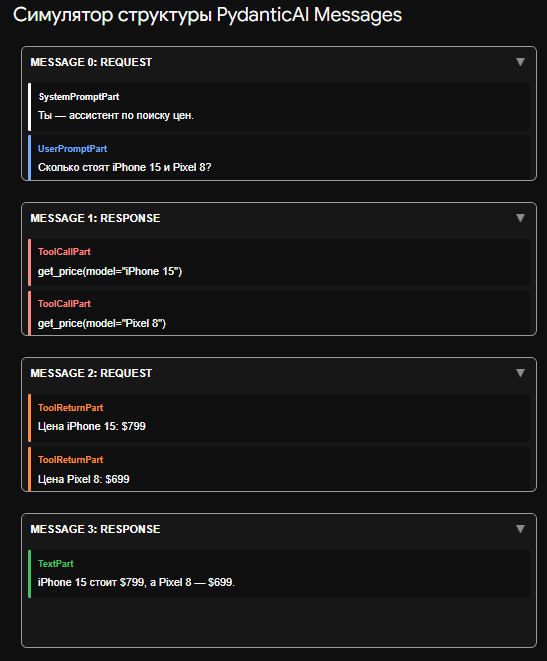

### Последовательное исправление

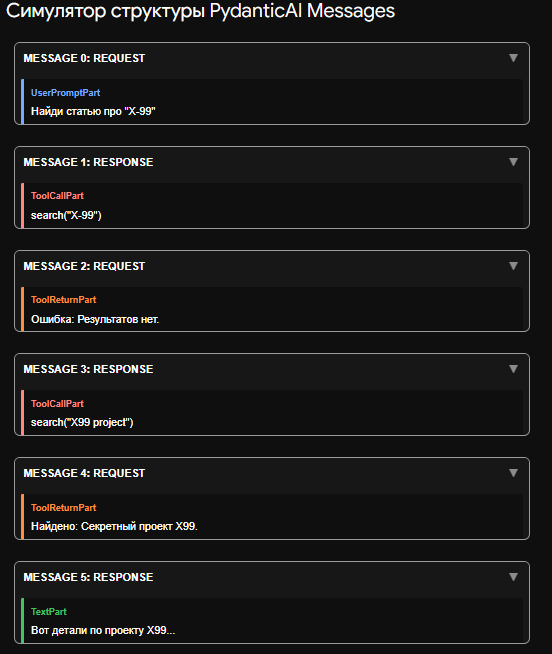

### Langchain

In [61]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

from langgraph.prebuilt import create_react_agent 

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", 
    google_api_key=os.getenv('GEMINI_API_KEY')
)


@tool
def search_course(query: str) -> str:
    """
    Search the lesson pages for entries matching the given query.
    Args:
        query: A SINGLE string containing the search query parameter.
    """
    results = index_chunks.search(query, num_results=5, boost_dict={'filename': 2.0, 'content': 1.0})
    
    lines = []
    for doc in results:
        lines.append(f"File: {doc['filename']}")
        lines.append(doc['content'])
        lines.append('')
        
    return '\n'.join(lines).strip()


system_prompt = """
You're a course teaching assistant. Answer the student's question using the search tool. 
Make multiple searches with different keywords before answering.
DO NOT answer from internal knowledge, use the search tool.
"""

agent_executor = create_react_agent(
    llm, 
    tools=[search_course], 
    prompt=agent_instructions
)


query = "How does the agentic loop work, and how is it different from plain RAG?"
result = agent_executor.invoke({"messages": [("user", query)]})

# 5. Считаем вызовы
call_count = 0
for msg in result["messages"]:
    if msg.type == "tool":
        call_count += 1
        print(f"[{call_count}] Search tool worked")

print(f"\nCalls num: {call_count}")
print("\nFinal Answer")
print(result["messages"][-1].content)

/tmp/ipykernel_4765/4252094520.py:37: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


[1] Search tool worked
[2] Search tool worked

Calls num: 2

Final Answer
[{'type': 'text', 'text': 'To understand the difference, it helps to look at how each operates as a system.\n\n### Plain RAG (Retrieval-Augmented Generation)\nPlain RAG is a **deterministic, linear pipeline**. It follows a fixed, pre-defined sequence of steps every time it runs:\n1.  **Retrieve:** Take the user query and search for relevant documents.\n2.  **Augment:** Insert those documents into a prompt template.\n3.  **Generate:** Send the prompt to the LLM to get an answer.\n\nIn this model, the "logic" is hardcoded. The system does not decide *if* it needs more information or *which* tool to use—it simply executes the same search-then-generate flow for every request.\n\n### The Agentic Loop\nThe agentic loop is **dynamic and iterative**. Instead of a fixed sequence, you give the LLM a goal and a set of "tools" (like search, calculators, or APIs) it can use to achieve that goal. \n\nThe loop works like this:\

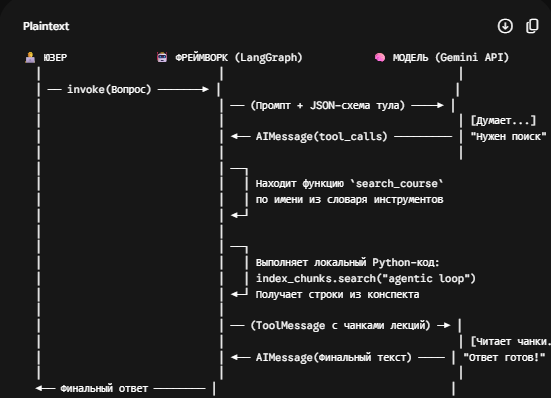

<!-- [ ПОЛЬЗОВАТЕЛЬ ]
               │
               ▼  (1) Запрос: "How does the agentic loop work...?"
         HumanMessage
               │
               ▼
         ┌───────────┐
         │    LLM    │ ◄─────────────────────────┐
         │ (Gemini)  │                           │
         └─────┬─────┘                           │
               │                                 │
               ▼  (2) Решение вызвать поиск      │ (4) Финальный ответ
          AIMessage                              │    AIMessage
         (tool_calls)                            │  (сгенерированный текст)
               │                                 │
               ▼                                 │
         ┌───────────┐                           │
         │ Инструмент│                           │
         │  (search) │                           │
         └─────┬─────┘                           │
               │                                 │
               ▼  (3) Результаты из minsearch    │
          ToolMessage  ──────────────────────────┘ -->